In [2]:
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm
np.random.seed(0); plt.rcParams["figure.figsize"] = (8, 3.6)
df = pd.read_parquet("../inputs/cartera.parquet")

# A. Exploración de las variables de interes

Describan su ramo y exploren **solo** las variables que importan: la distribución de número de sinsitrsos, exposición y monto de siniestro. Reporten los descriptivos básicos (media, mediana, forma de la cola). No hagan un tour por todo el dataset: enfóquense.

In [3]:
print("Pólizas:", len(df), "| Columnas:", len(df.columns))
print("  frecuencia : num_siniestros, exposicion")
print("  severidad  : monto_promedio_siniestro (ground-up)")
print("  póliza     : deducible, suma_asegurada, coaseguro (para transformar)")

Pólizas: 30000 | Columnas: 13
  frecuencia : num_siniestros, exposicion
  severidad  : monto_promedio_siniestro (ground-up)
  póliza     : deducible, suma_asegurada, coaseguro (para transformar)


Tasa de frecuencia siniestral: 2.2%
Exposición total              : 24,003 años-póliza
Severidad (monto_promedio)    → media 1,024,668.77 mediana 143,554 


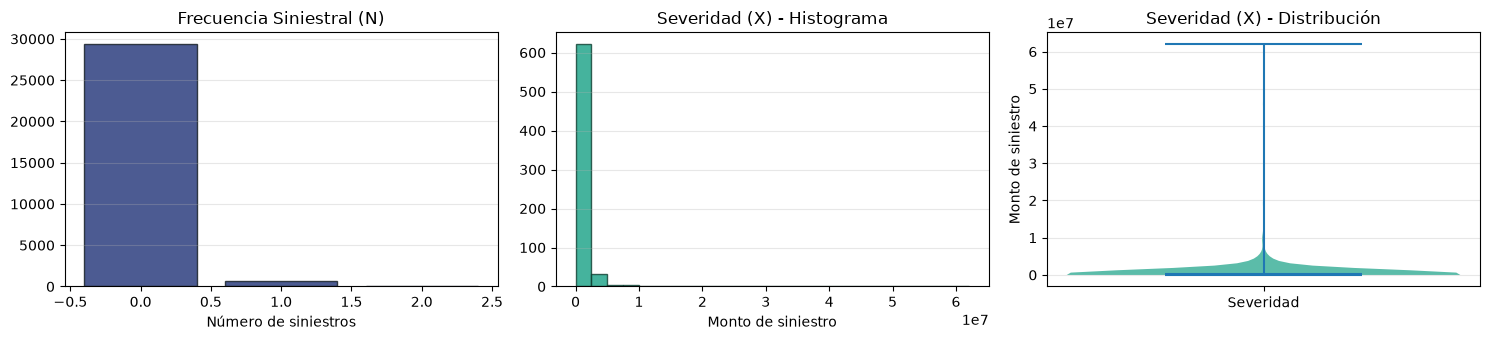

In [4]:
# Exploración enfocada en componentes de la prima pura
 
# Filtrar pólizas con siniestros para estimar E[X] (severidad)
con = df[df.num_siniestros > 0]
 
# Tasa de frecuencia siniestral: proporción de pólizas con ≥1 siniestro
print(f"Tasa de frecuencia siniestral: {(df.num_siniestros>0).mean():.1%}")
 
# Exposición total en años-póliza: normaliza las métricas en el tiempo
print(f"Exposición total              : {df.exposicion.sum():,.0f} años-póliza")
 
# Severidad (E[X]): monto promedio por siniestro en pólizas siniestradas
print(f"Severidad (monto_promedio)    → media {con.monto_promedio_siniestro.mean():,.2f} "
      f"mediana {con.monto_promedio_siniestro.median():,.0f} ")

fig, ax = plt.subplots(1, 3, figsize=(15, 3.5))
 
# Frecuencia N: variable discreta
# Muestra la distribución de conteos de siniestros para revisar si hay Poisson o sobredispersión
ax[0].bar(*np.unique(df.num_siniestros, return_counts=True), color="#2C3E7F", edgecolor="#1A232A", alpha=0.85)
ax[0].set_title("Frecuencia Siniestral (N)"); ax[0].set_xlabel("Número de siniestros")
ax[0].grid(axis='y', alpha=0.3)
 
# Severidad X - Histograma: muestra densidad de frecuencia en rangos de montos
# Útil para ver dónde se concentran los valores y detectar multimodalidad
ax[1].hist(con.monto_promedio_siniestro, bins=int(np.sqrt(len(con))), color="#16A085", edgecolor="#0D3D2F", alpha=0.8)
ax[1].set_title("Severidad (X) - Histograma"); ax[1].set_xlabel("Monto de siniestro")
ax[1].grid(axis='y', alpha=0.3)
 
# Severidad X - Violin plot: muestra cuartiles, mediana y forma de la distribución
# Mejor para comparar asimetría y cola pesada; ve directamente la estructura del riesgo
parts = ax[2].violinplot([con.monto_promedio_siniestro], orientation='vertical', showmedians=True, showextrema=True)
for pc in parts['bodies']:
    pc.set_facecolor("#16A085")
    pc.set_alpha(0.7)
ax[2].set_title("Severidad (X) - Distribución"); ax[2].set_ylabel("Monto de siniestro")
ax[2].set_xticks([1]); ax[2].set_xticklabels(['Severidad'])
ax[2].grid(axis='y', alpha=0.3)
 
plt.tight_layout(); plt.show()